In [2043]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from scipy import signal

from v2_data_preparation import slice_by_dates, handle_missing_values, load_and_prepare_data, process_insitu

#### Preprocesamiento SAR

##### Normalizacion de observaciones SAR con angulo constante

Asmub et al 2019 aplican una normalizacion a los datos de retrodispersion para minimizar el efecto del angulo de incidencia sobre los datos. El metodo consiste en determinar la relacion lineal entre backscatter y angulo de incidencia y luego ajustar cada observación a un ángulo de referencia (mitad del rango observado == 38.5) utilizando dicha relacion.

In [2044]:
sar = pd.read_csv("../data/processed/satellites/SDH1_S1_2014-10_2026-09_Mono_Lee_12x12_dB.csv")

# 1. Asegurar tipo numérico y filtrar filas con NaN o infinitos en las columnas clave
sar['angle'] = pd.to_numeric(sar['angle'], errors='coerce')
sar['VV'] = pd.to_numeric(sar['VV'], errors='coerce')

# Máscara de datos válidos para el ajuste
valid_mask = sar['angle'].notna() & sar['VV'].notna() & np.isfinite(sar['angle']) & np.isfinite(sar['VV'])

# 2. Calcular la pendiente usando solo datos válidos
beta, intercept = np.polyfit(sar.loc[valid_mask, 'angle'], sar.loc[valid_mask, 'VV'], deg=1)
print(f"Pendiente constante (beta) estimada: {beta:.4f} dB/Grado")
print(f"Intercepto estimado: {intercept:.4f} dB")

# 3. Definir el ángulo de referencia
ref_angle = 38.5

# 4. Aplicar la ecuación de normalización (los NaN se mantendrán como NaN sin romper el cálculo)
col_name = f'VV_{ref_angle}'
sar[col_name] = sar['VV'] - beta * (sar['angle'] - ref_angle)

# Visualizar el resultado omitiendo NaN
print(sar[['Timestamps', 'angle', 'VV', col_name]].dropna().tail())

Pendiente constante (beta) estimada: -0.2889 dB/Grado
Intercepto estimado: -3.8956 dB
      Timestamps      angle         VV    VV_38.5
1293  2026-08-26  32.682583 -11.862978 -13.543546
1294  2026-09-02  44.935013 -16.043410 -14.184427
1295  2026-09-07  32.683960 -10.529031 -12.209201
1296  2026-09-13  37.583370 -10.788711 -11.053512
1297  2026-09-14  44.936119 -13.759456 -11.900154


##### Resampleo semanal SAR

In [2045]:
sar["Timestamps"] = pd.to_datetime(sar["Timestamps"], format="%Y-%m-%d")

In [2046]:
sar_cleaned = sar.drop_duplicates(
    subset=["Timestamps"], keep="first").set_index(
        "Timestamps").sort_index()

In [2047]:
df_cleaned_clip = slice_by_dates(sar_cleaned, '2024-05', '2026-07-05')

In [2048]:
# Convertir dB a escala lineal antes de resamplear. Usa la VV normalizada
# lineal = 10^(dB / 10)
sar_cleaned['VV_linear'] = 10 ** (sar_cleaned[col_name] / 10)

# Reindexar a frecuencia semanal
sar_weekly = sar_cleaned[['VV_linear']].resample('W').mean()

sar_weekly

,VV_linear
Timestamps,
2014-10-19,0.031542
2014-10-26,NaN
2014-11-02,NaN
2014-11-09,NaN
2014-11-16,NaN
...,...
2026-08-23,0.042742
2026-08-30,0.068326
2026-09-06,0.046340


In [2049]:
# Recorte a periodo donde NaN no ocurren dos semanas seguidas e interpolacion lineal de NaNs
sar_weekly_clip = (
    slice_by_dates(sar_weekly, '2017-02', '2026-07-05')
    .pipe(handle_missing_values, method='time')
)

In [2050]:
# Volver a convertir el promedio semanal a dB
sar_weekly_clip[f'{col_name}_weekly'] = 10 * np.log10(sar_weekly_clip['VV_linear'])

# Eliminar columna auxiliar lineal
sar_weekly = sar_weekly_clip.drop(columns=['VV_linear'])

In [2051]:
sar_weekly_2024 = slice_by_dates(sar_weekly, '2024-05')

#### Preprocesamiento datos in-situ

##### Resampleo observaciones 2024-2026 y visualizacion diaria y semanal

In [2052]:
insitu = process_insitu(
    filepath='../data/processed/in-situ/SDH1_daily-insitu-data.csv',
    start_date='2024-05-22',
    end_date='2026-05-14',
    cols_to_keep=['SDH1PS01_gw-depth_m', 'ATMOS41_precipitation_mm'],
    outlier_threshold=3,
    ignore_outliers_cols=['ATMOS41_precipitation_mm']
)

In [2053]:
insitu_weekly = insitu.resample('W').agg({
    'SDH1PS01_gw-depth_m': 'mean',
    'ATMOS41_precipitation_mm': 'sum'
})

In [2054]:
insitu_weekly

,SDH1PS01_gw-depth_m,ATMOS41_precipitation_mm
2024-05-26,-0.607000,0.000
2024-06-02,-0.658000,0.000
2024-06-09,-0.665286,0.000
2024-06-16,-0.652143,0.000
2024-06-23,-0.641714,0.000
...,...,...
2026-04-19,-0.598429,0.102
2026-04-26,-0.593143,0.102
2026-05-03,-0.598857,0.000
2026-05-10,-0.588143,0.000


Nivel freatico y precipitaciones vs backscatter normalizado (semanal y regular)

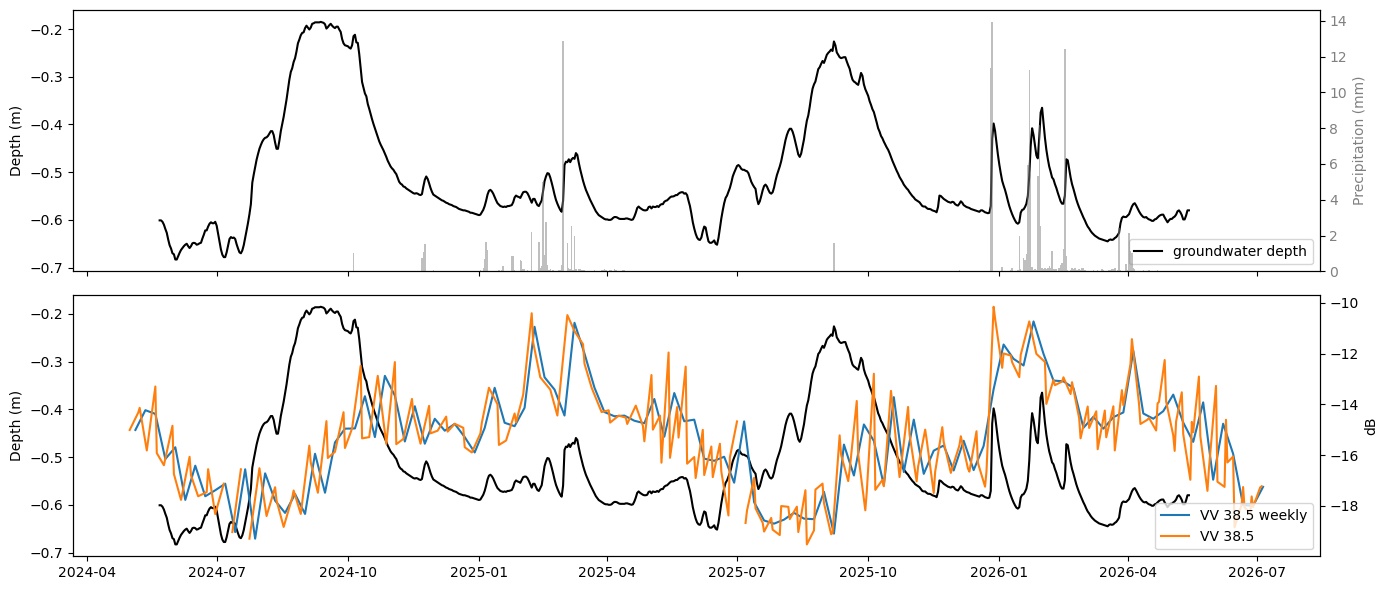

In [2055]:
# Figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Plot superior
ax1.plot(insitu.index, insitu['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
ax1.set_ylabel('Depth (m)')
ax1.legend(loc='lower right')

ax3 = ax1.twinx()
ax3.bar(insitu.index, insitu['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax3.set_ylabel('Precipitation (mm)', color='gray')
ax3.tick_params(axis='y', labelcolor='gray')

# Plot inferior
ax2.plot(insitu.index, insitu['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
ax2.set_ylabel('Depth (m)')

ax4 = ax2.twinx()
ax4.plot(sar_weekly_2024.index, sar_weekly_2024['VV_38.5_weekly'], label = 'VV 38.5 weekly')
ax4.plot(df_cleaned_clip.index, df_cleaned_clip['VV_38.5'], label = 'VV 38.5')
ax4.legend(loc='lower right')
ax4.set_ylabel('dB')

plt.tight_layout()
plt.show()

Nivel freatico y precipitaciones semanales vs backscatter normalizado semanal

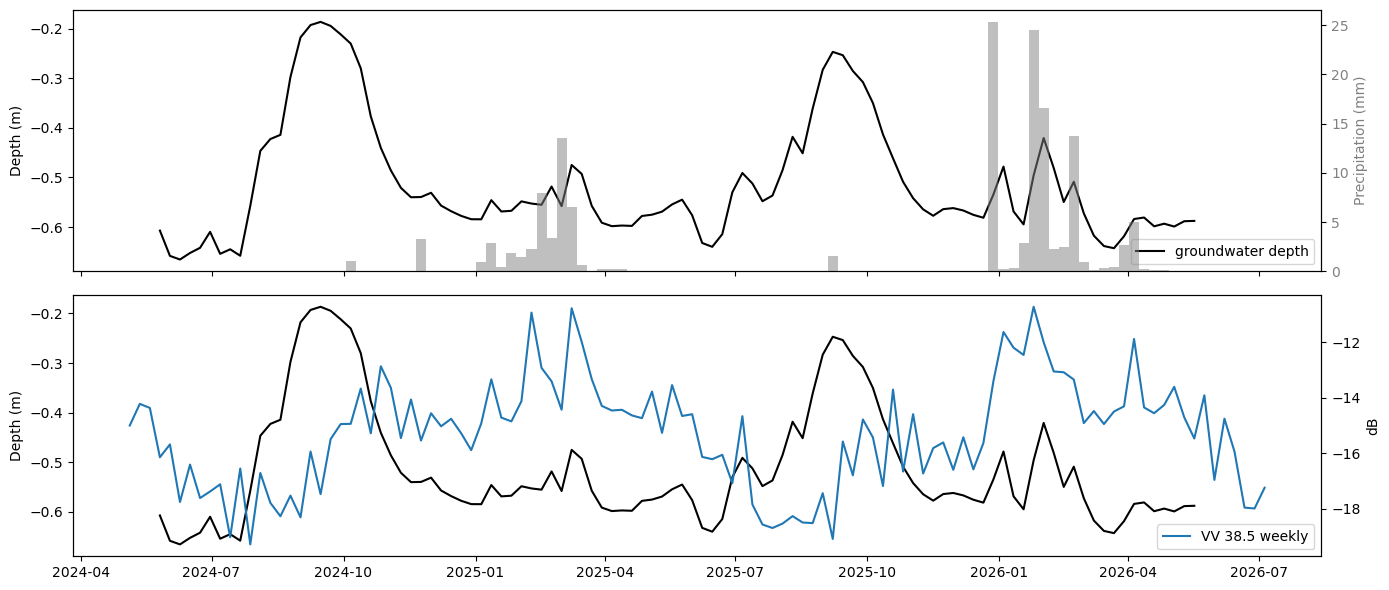

In [2056]:
# Figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Plot superior
ax1.plot(insitu_weekly.index, insitu_weekly['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
ax1.set_ylabel('Depth (m)')
ax1.legend(loc='lower right')

ax3 = ax1.twinx()
ax3.bar(insitu_weekly.index, insitu_weekly['ATMOS41_precipitation_mm'], width=7, color='gray', alpha=0.5, label='Precipitation (mm)')
ax3.set_ylabel('Precipitation (mm)', color='gray')
ax3.tick_params(axis='y', labelcolor='gray')

# Plot inferior
ax2.plot(insitu_weekly.index, insitu_weekly['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black')
ax2.set_ylabel('Depth (m)')

ax4 = ax2.twinx()
ax4.plot(sar_weekly_2024.index, sar_weekly_2024['VV_38.5_weekly'], label = 'VV 38.5 weekly')
ax4.legend(loc='lower right')
ax4.set_ylabel('dB')

plt.tight_layout()
plt.show()

In [2057]:
daily_df = insitu.join(sar_cleaned, how='outer')
daily_df = slice_by_dates(daily_df, '2024-05-22', '2026-05-14')

In [2058]:
weekly_df = insitu_weekly.join(sar_weekly_2024, how='inner')
weekly_df = slice_by_dates(weekly_df, '2024-05', '2026-06')

In [2059]:
# weekly_df = slice_by_dates(weekly_df, '2024-05', '2024-12')

In [2060]:
weekly_df

,SDH1PS01_gw-depth_m,ATMOS41_precipitation_mm,VV_38.5_weekly
2024-05-26,-0.607000,0.000,-16.149128
2024-06-02,-0.658000,0.000,-15.686225
2024-06-09,-0.665286,0.000,-17.759720
2024-06-16,-0.652143,0.000,-16.412538
2024-06-23,-0.641714,0.000,-17.617411
...,...,...,...
2026-04-19,-0.598429,0.102,-14.562078
2026-04-26,-0.593143,0.102,-14.264556
2026-05-03,-0.598857,0.000,-13.612634
2026-05-10,-0.588143,0.000,-14.712328


#### CCF iteracion A: series sin transformaciones estadísticas

Función para implementar el método XBH propuesto por Gao et al 2024

In [2061]:
def cross_correlation_xbh(x, y, max_lag, alpha=0.05):
    """
    Calcula la correlación cruzada y los umbrales críticos de significación 
    siguiendo el método xBH de Gao et al. (2024).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    N = len(x)
    
    if len(y) != N:
        raise ValueError("Las series x e y deben tener la misma longitud N.")
    
    # 1. Estandarización (desmedido y escala)
    x_c = x - np.mean(x)
    y_c = y - np.mean(y)
    
    std_x = np.std(x_c, ddof=0)
    std_y = np.std(y_c, ddof=0)
    
    # 2. Autocorrelaciones muestrales completas
    autocorr_x = np.correlate(x_c, x_c, mode='full')[N-1:] / (N * std_x**2)
    autocorr_y = np.correlate(y_c, y_c, mode='full')[N-1:] / (N * std_y**2)
    
    lags = np.arange(-max_lag, max_lag + 1)
    n_tau = len(lags)
    
    ccf = np.zeros(n_tau)
    delta = np.zeros(n_tau)
    v_eff = np.zeros(n_tau)
    rho_c = np.zeros(n_tau)
    
    # 3. Cálculo de CCF y delta(tau) para cada lag
    for idx, tau in enumerate(lags):
        abs_tau = abs(tau)
        N_sub = N - abs_tau
        
        if tau >= 0:
            cxy = np.sum(x_c[:N_sub] * y_c[tau:]) / N
        else:
            cxy = np.sum(x_c[abs_tau:] * y_c[:N_sub]) / N
            
        ccf[idx] = cxy / (std_x * std_y)
        
        # Factor xBH: Ec. (5)
        k = np.arange(1, N_sub)
        weight = (N_sub - k) / N_sub
        sum_term = np.sum(weight * autocorr_x[k] * autocorr_y[k])
        
        denom = 1.0 + 2.0 * sum_term
        delta[idx] = 1.0 / denom if denom > 0 else 0.0
        
        # Grados de libertad efectivos: Ec. (4)
        v_eff[idx] = max(N_sub * delta[idx] - 2.0, 1.0)
        
    # 4. Ajuste por búsqueda de rango: Ecs. (6) y (7)
    delta_0 = delta[n_tau // 2]  # delta en tau = 0
    n_i = max(n_tau * delta_0, 1.0)
    alpha_c = 1.0 - (1.0 - alpha)**(1.0 / n_i)
    
    # 5. Coeficiente crítico para cada tau: Ec. (8)
    for idx, tau in enumerate(lags):
        abs_tau = abs(tau)
        t_crit = stats.t.ppf(1.0 - alpha_c / 2.0, df=v_eff[idx])
        rho_c[idx] = ((N - abs_tau) / N) * (t_crit / np.sqrt(v_eff[idx] + t_crit**2))
        
    # Identificar si la correlación observada es significativa
    is_significant = np.abs(ccf) >= rho_c
    
    return {
        'lags': lags,
        'ccf': ccf,
        'rho_critical': rho_c,
        'is_significant': is_significant,
        'v_effective': v_eff,
        'delta': delta,
        'n_independent': n_i,
        'alpha_adjusted': alpha_c
    }

In [2062]:
xbh_res = cross_correlation_xbh(
    x=weekly_df['SDH1PS01_gw-depth_m'],
    y=weekly_df['VV_38.5_weekly'],
    max_lag=10,
    alpha=0.05
)

In [2063]:
xbh_res

{'lags': array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
          3,   4,   5,   6,   7,   8,   9,  10]),
 'ccf': array([-0.53912851, -0.58876253, -0.62772821, -0.64811413, -0.64248703,
        -0.58428198, -0.524013  , -0.48324084, -0.40044968, -0.2787362 ,
        -0.16227026, -0.10836695, -0.05412377,  0.01416909,  0.05421073,
         0.09532958,  0.11354617,  0.11414214,  0.11405542,  0.10176059,
         0.09736046]),
 'rho_critical': array([0.59247668, 0.59657734, 0.60064842, 0.60469174, 0.60870801,
        0.61269822, 0.61666297, 0.62060292, 0.6245186 , 0.62841046,
        0.63227894, 0.62841046, 0.6245186 , 0.62060292, 0.61666297,
        0.61269822, 0.60870801, 0.60469174, 0.60064842, 0.59657734,
        0.59247668]),
 'is_significant': array([False, False,  True,  True,  True, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 'v_effective': array([10.26161087, 10.3591605

Funciones para aplicar la validación con simulaciones de Monte Carlo dado que los grados de libertad efectivos en mi caso son < 35 (recomendación de Gao et al 2024)

In [2064]:
def generate_fft_surrogate(signal):
    """
    Generate surrogate time series preserving autocorrelation via FFT phase randomization.
    Follows Prichard and Theiler (1994) as specified in Gao et al. (2024).
    """
    signal_length = len(signal)
    centered_signal = signal - np.mean(signal)
    
    # Compute real discrete Fourier transform
    fourier_transform = np.fft.rfft(centered_signal)
    spectral_amplitudes = np.abs(fourier_transform)
    num_frequencies = len(fourier_transform)
    
    # Generate random phase shifts uniformly in [0, 2*pi)
    random_phases = np.random.uniform(0.0, 2.0 * np.pi, size=num_frequencies)
    
    # Preserve DC component phase to maintain real-valued signal baseline
    random_phases[0] = 0.0
    
    # Preserve Nyquist frequency phase if sample length is even
    if signal_length % 2 == 0:
        random_phases[-1] = 0.0
        
    # Reconstruct surrogate signal with randomized phases
    surrogate_spectrum = spectral_amplitudes * np.exp(1j * random_phases)
    surrogate_signal = np.fft.irfft(surrogate_spectrum, n=signal_length)
    
    return surrogate_signal


def compute_cross_correlation_series(x_signal, y_signal, max_lag):
    """
    Calculate sample cross-correlation coefficients across a specified lag range.
    Implements Equations (1) and (2) from Gao et al. (2024).
    """
    sample_size = len(x_signal)
    centered_x = x_signal - np.mean(x_signal)
    centered_y = y_signal - np.mean(y_signal)
    
    std_x = np.std(centered_x, ddof=0)
    std_y = np.std(centered_y, ddof=0)
    
    if std_x == 0.0 or std_y == 0.0:
        raise ValueError("Standard deviation of one or both input series is zero.")
        
    lags = np.arange(-max_lag, max_lag + 1)
    num_lags = len(lags)
    ccf_values = np.zeros(num_lags, dtype=float)
    
    for lag_index, tau in enumerate(lags):
        abs_tau = abs(tau)
        sub_length = sample_size - abs_tau
        
        if tau >= 0:
            covariance = np.sum(centered_x[:sub_length] * centered_y[tau:]) / sample_size
        else:
            covariance = np.sum(centered_x[abs_tau:] * centered_y[:sub_length]) / sample_size
            
        ccf_values[lag_index] = covariance / (std_x * std_y)
        
    return lags, ccf_values


def monte_carlo_cross_correlation(x, y, max_lag, num_simulations=2000, alpha=0.05, random_seed=None):
    """
    Perform Monte Carlo significance test for cross-correlation using FFT phase-randomized surrogates.
    Computes both pointwise critical values and the range-adjusted peak threshold.
    """
    if random_seed is not None:
        np.random.seed(random_seed)
        
    x_array = np.asarray(x, dtype=float)
    y_array = np.asarray(y, dtype=float)
    
    if len(x_array) != len(y_array):
        raise ValueError("Series x and y must have the same length.")
        
    # 1. Compute empirical cross-correlation for the observed data
    lags, observed_ccf = compute_cross_correlation_series(x_array, y_array, max_lag)
    num_lags = len(lags)
    
    observed_peak_index = np.argmax(np.abs(observed_ccf))
    observed_peak_lag = lags[observed_peak_index]
    observed_peak_correlation = observed_ccf[observed_peak_index]
    
    # 2. Allocate matrices for surrogate runs
    surrogate_pointwise_abs_ccf = np.zeros((num_simulations, num_lags), dtype=float)
    surrogate_peak_abs_ccf = np.zeros(num_simulations, dtype=float)
    
    # 3. Execute Monte Carlo iterations using FFT surrogates
    for sim_index in range(num_simulations):
        # Generate surrogate keeping the exact autocorrelation structure of y
        surrogate_y = generate_fft_surrogate(y_array)
        
        # Calculate cross-correlation between observed x and surrogate y
        _, sim_ccf = compute_cross_correlation_series(x_array, surrogate_y, max_lag)
        abs_sim_ccf = np.abs(sim_ccf)
        
        surrogate_pointwise_abs_ccf[sim_index, :] = abs_sim_ccf
        surrogate_peak_abs_ccf[sim_index] = np.max(abs_sim_ccf)
        
    # 4. Derive empirical critical thresholds by sorting percentiles
    percentile_level = (1.0 - alpha) * 100.0
    critical_threshold_pointwise = np.percentile(surrogate_pointwise_abs_ccf, percentile_level, axis=0)
    critical_threshold_peak = np.percentile(surrogate_peak_abs_ccf, percentile_level)
    
    # 5. Calculate empirical p-value for the observed peak within the searched range
    empirical_p_value = np.mean(surrogate_peak_abs_ccf >= np.abs(observed_peak_correlation))
    is_peak_significant = bool(empirical_p_value < alpha)
    
    return {
        'lags': lags,
        'observed_ccf': observed_ccf,
        'peak_lag': observed_peak_lag,
        'peak_correlation': observed_peak_correlation,
        'critical_threshold_pointwise': critical_threshold_pointwise,
        'critical_threshold_peak': critical_threshold_peak,
        'empirical_p_value': empirical_p_value,
        'is_peak_significant': is_peak_significant
    }

In [2065]:
results_mc = monte_carlo_cross_correlation(
    x=weekly_df['SDH1PS01_gw-depth_m'],
    y=weekly_df['VV_38.5_weekly'],
    max_lag=10,
    num_simulations=2000,
    alpha=0.05,
    random_seed=42
)

print(f"Desfase del pico: {results_mc['peak_lag']} semanas")
print(f"Correlación del pico: {results_mc['peak_correlation']:.4f}")
print(f"Umbral crítico para el pico (MC 95%): {results_mc['critical_threshold_peak']:.4f}")
print(f"Valor p empírico: {results_mc['empirical_p_value']:.4f}")
print(f"¿Significativo en el rango?: {results_mc['is_peak_significant']}")

Desfase del pico: -7 semanas
Correlación del pico: -0.6481
Umbral crítico para el pico (MC 95%): 0.6726
Valor p empírico: 0.1045
¿Significativo en el rango?: False


In [2066]:
results_mc

{'lags': array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
          3,   4,   5,   6,   7,   8,   9,  10]),
 'observed_ccf': array([-0.53912851, -0.58876253, -0.62772821, -0.64811413, -0.64248703,
        -0.58428198, -0.524013  , -0.48324084, -0.40044968, -0.2787362 ,
        -0.16227026, -0.10836695, -0.05412377,  0.01416909,  0.05421073,
         0.09532958,  0.11354617,  0.11414214,  0.11405542,  0.10176059,
         0.09736046]),
 'peak_lag': np.int64(-7),
 'peak_correlation': np.float64(-0.6481141277549541),
 'critical_threshold_pointwise': array([0.5866519 , 0.58327138, 0.58340346, 0.59178351, 0.59340885,
        0.58531686, 0.58974132, 0.58485776, 0.59225902, 0.59746931,
        0.60355899, 0.60392909, 0.59667583, 0.58830962, 0.5848765 ,
        0.57885277, 0.57473227, 0.56622333, 0.55992775, 0.54755292,
        0.53475741]),
 'critical_threshold_peak': np.float64(0.672567252486946),
 'empirical_p_value': np.float64(0.1045),
 'is_peak_significant': False}

Los resultados muestran que la autocorrelación de las series es demasiado alta, lo que reduce los grados de libertad efectivos y aumenta el umbral de CCF crítico, por lo que es necesario reducir las autocorrelaciones mediante transformaciones matemáticas, como hacen Gao et al 2024.

#### CCF iteracion B: con transformacion de series SAR y nivel freatico

##### Evaluación de señales anuales e intranuales

In [2067]:
def analyze_series_diagnostics(time_series, sample_rate_per_year=52.0, max_lags=60):
    """
    Compute power spectral density and autocorrelation to diagnose seasonal cycles and persistence.
    """
    series_array = np.asarray(time_series, dtype=float)
    num_samples = len(series_array)
    centered_series = series_array - np.mean(series_array)
    variance = np.var(centered_series, ddof=0)
    
    # 1. Compute power spectral density using Welch's method
    frequencies, power_spectrum = signal.welch(
        centered_series, 
        fs=sample_rate_per_year, 
        nperseg=min(num_samples, 104)
    )
    
    # 2. Compute autocorrelation function
    full_autocorr = np.correlate(centered_series, centered_series, mode='full')
    autocorr = full_autocorr[num_samples - 1:num_samples + max_lags] / (num_samples * variance)
    lag_indices = np.arange(len(autocorr))
    
    return {
        'frequencies': frequencies,
        'power_spectrum': power_spectrum,
        'lags': lag_indices,
        'autocorrelation': autocorr
    }


def plot_series_diagnostics(diagnostics_x, diagnostics_y, label_x="level", label_y="backscatter"):
    """
    Plot spectral density and autocorrelation curves to evaluate periodicities.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Spectrum series X
    axes[0, 0].plot(diagnostics_x['frequencies'], diagnostics_x['power_spectrum'], color='tab:blue')
    axes[0, 0].axvline(1.0, color='red', linestyle='--', label='1 year (52 weeks)')
    axes[0, 0].axvline(2.0, color='orange', linestyle=':', label='6 months (26 weeks)')
    axes[0, 0].set_title(f"power spectrum: {label_x}")
    axes[0, 0].set_xlabel("frequency (cycles/year)")
    axes[0, 0].set_ylabel("density")
    axes[0, 0].legend()
    
    # Spectrum series Y
    axes[0, 1].plot(diagnostics_y['frequencies'], diagnostics_y['power_spectrum'], color='tab:green')
    axes[0, 1].axvline(1.0, color='red', linestyle='--', label='1 year (52 weeks)')
    axes[0, 1].axvline(2.0, color='orange', linestyle=':', label='6 months (26 weeks)')
    axes[0, 1].set_title(f"power spectrum: {label_y}")
    axes[0, 1].set_xlabel("frequency (cycles/year)")
    axes[0, 1].set_ylabel("density")
    axes[0, 1].legend()
    
    # Autocorrelation series X
    axes[1, 0].stem(diagnostics_x['lags'], diagnostics_x['autocorrelation'])
    axes[1, 0].axhline(0, color='black', linewidth=0.8)
    axes[1, 0].set_title(f"autocorrelation function: {label_x}")
    axes[1, 0].set_xlabel("lag (weeks)")
    axes[1, 0].set_ylabel("correlation")
    
    # Autocorrelation series Y
    axes[1, 1].stem(diagnostics_y['lags'], diagnostics_y['autocorrelation'])
    axes[1, 1].axhline(0, color='black', linewidth=0.8)
    axes[1, 1].set_title(f"autocorrelation function: {label_y}")
    axes[1, 1].set_xlabel("lag (weeks)")
    axes[1, 1].set_ylabel("correlation")
    
    plt.tight_layout()
    plt.show()

In [2068]:
diagnostic_level = analyze_series_diagnostics(weekly_df['SDH1PS01_gw-depth_m'])
diagnostic_sar = analyze_series_diagnostics(weekly_df['VV_38.5_weekly'])

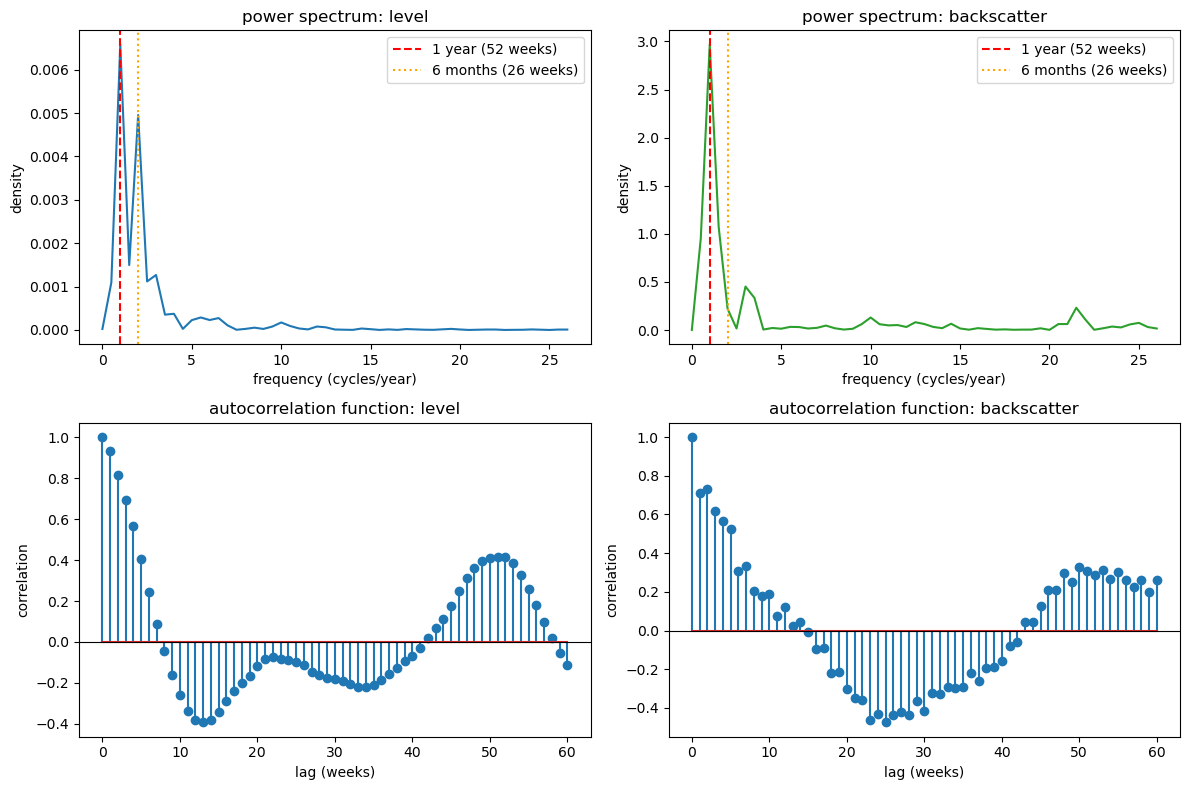

In [2069]:
plot_series_diagnostics(diagnostic_level, diagnostic_sar)

Los gráficos superiores muestran que el nivel freático tiene dos señales anuales (52 y 26 semanas), mientras que el backscatter una (52 semanas). Los gráficos inferiores confirman el comportamiento, pero no tengo claro cómo explicarlo.

##### Desestacionalizacion de series SAR y nivel freatico

In [2070]:
def fit_harmonics_and_detrend(signal, sample_rate_per_year=52.0, num_harmonics=2):
    """
    Remove mean, linear trend, and seasonal periodic signals using least squares regression.
    Follows the preprocessing strategy outlined in Section 3 of Gao et al. (2024).
    """
    num_samples = len(signal)
    time_steps = np.arange(num_samples, dtype=float)
    
    # Construct design matrix: constant term and linear trend
    design_matrix_columns = [np.ones(num_samples, dtype=float), time_steps]
    
    # Add annual and sub-annual harmonic components (e.g., annual and semiannual)
    for harmonic_order in range(1, num_harmonics + 1):
        angular_frequency = 2.0 * np.pi * harmonic_order / sample_rate_per_year
        cosine_component = np.cos(angular_frequency * time_steps)
        sine_component = np.sin(angular_frequency * time_steps)
        design_matrix_columns.extend([cosine_component, sine_component])
        
    design_matrix = np.column_stack(design_matrix_columns)
    
    # Solve ordinary least squares: design_matrix * coefficients = signal
    regression_coefficients, _, _, _ = np.linalg.lstsq(design_matrix, signal, rcond=None)
    
    # Reconstruct fitted deterministic signal
    fitted_signal = design_matrix @ regression_coefficients
    
    # Extract residuals (anomalies)
    residual_anomalies = signal - fitted_signal
    
    return residual_anomalies, fitted_signal


def preprocess_geophysical_series(x_signal, y_signal, sample_rate_per_year=52.0, num_harmonics=2):
    """
    Apply full detrending, harmonic removal, and unit variance scaling to a pair of series.
    """
    # 1. Extract seasonal anomalies for both series
    x_anomalies, _ = fit_harmonics_and_detrend(
        signal=x_signal, 
        sample_rate_per_year=sample_rate_per_year, 
        num_harmonics=num_harmonics
    )
    y_anomalies, _ = fit_harmonics_and_detrend(
        signal=y_signal, 
        sample_rate_per_year=sample_rate_per_year, 
        num_harmonics=num_harmonics
    )
    
    # 2. De-mean and normalize to unit standard deviation (Gao et al. 2024, Section 3)
    x_normalized = (x_anomalies - np.mean(x_anomalies)) / np.std(x_anomalies, ddof=0)
    y_normalized = (y_anomalies - np.mean(y_anomalies)) / np.std(y_anomalies, ddof=0)
    
    return x_normalized, y_normalized

In [2071]:
# 1. Obtener anomalías desestacionalizadas
x_anom, y_anom = preprocess_geophysical_series(
    x_signal=weekly_df['SDH1PS01_gw-depth_m'],
    y_signal=weekly_df['VV_38.5_weekly'],
    sample_rate_per_year=52.0,
    num_harmonics=3
)

Al usar num_harmonis=3, en XBH los grados de libertad efectivos suben a >58 haciendo más valida su aplicacion.

<Axes: >

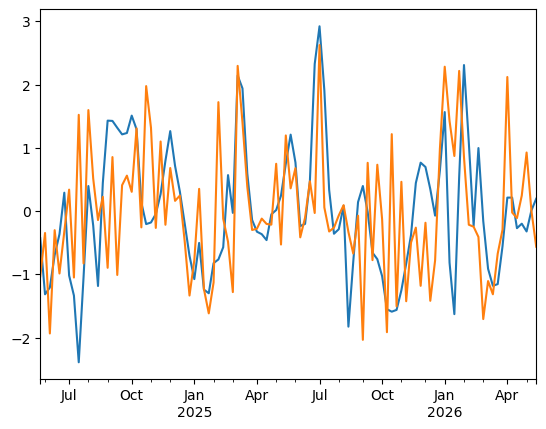

In [2072]:
x_anom.plot()
y_anom.plot()

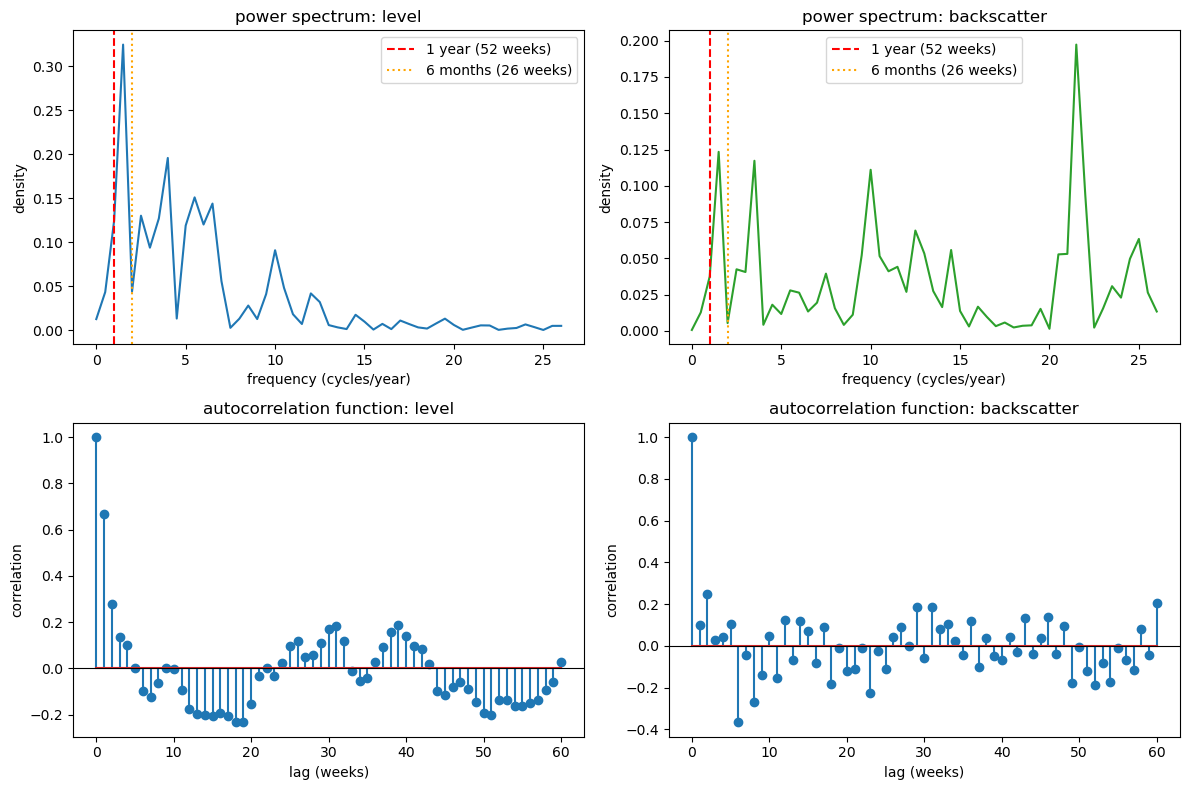

In [2073]:
diagnostic_level_norm = analyze_series_diagnostics(x_anom)
diagnostic_sar_norm = analyze_series_diagnostics(y_anom)

plot_series_diagnostics(diagnostic_level_norm, diagnostic_sar_norm)

##### Cálculo de CCF con series normalizadas

In [2074]:
xbh_res_norm = cross_correlation_xbh(
    x=x_anom,
    y=y_anom,
    max_lag=5,
    alpha=0.05
)
xbh_res_norm

{'lags': array([-5, -4, -3, -2, -1,  0,  1,  2,  3,  4,  5]),
 'ccf': array([0.20322195, 0.24811894, 0.11102314, 0.12628074, 0.27469249,
        0.37398461, 0.20244128, 0.07232963, 0.1044316 , 0.05063412,
        0.09375852]),
 'rho_critical': array([0.32423471, 0.32612006, 0.32799468, 0.32985878, 0.33171253,
        0.33355609, 0.33171253, 0.32985878, 0.32799468, 0.32612006,
        0.32423471]),
 'is_significant': array([False, False, False, False, False,  True, False, False, False,
        False, False]),
 'v_effective': array([58.07410281, 58.59757933, 59.12128995, 59.64521809, 60.16935893,
        60.69370557, 60.16935893, 59.64521809, 59.12128995, 58.59757933,
        58.07410281]),
 'delta': array([0.60680912, 0.60597579, 0.60516129, 0.60436488, 0.60358601,
        0.60282409, 0.60358601, 0.60436488, 0.60516129, 0.60597579,
        0.60680912]),
 'n_independent': np.float64(6.631065012199717),
 'alpha_adjusted': np.float64(0.0077054621317843575)}

In [2075]:
results_mc_norm = monte_carlo_cross_correlation(
    x=x_anom,
    y=y_anom,
    max_lag=5,
    num_simulations=2000,
    alpha=0.05,
    random_seed=42
)

print(f"Desfase del pico: {results_mc_norm['peak_lag']} semanas")
print(f"Correlación del pico: {results_mc_norm['peak_correlation']:.4f}")
print(f"Umbral crítico para el pico (MC 95%): {results_mc_norm['critical_threshold_peak']:.4f}")
print(f"Valor p empírico: {results_mc_norm['empirical_p_value']:.4f}")
print(f"¿Significativo en el rango?: {results_mc_norm['is_peak_significant']}")

Desfase del pico: 0 semanas
Correlación del pico: 0.3740
Umbral crítico para el pico (MC 95%): 0.3681
Valor p empírico: 0.0450
¿Significativo en el rango?: True


In [2076]:
results_mc_norm

{'lags': array([-5, -4, -3, -2, -1,  0,  1,  2,  3,  4,  5]),
 'observed_ccf': array([0.20322195, 0.24811894, 0.11102314, 0.12628074, 0.27469249,
        0.37398461, 0.20244128, 0.07232963, 0.1044316 , 0.05063412,
        0.09375852]),
 'peak_lag': np.int64(0),
 'peak_correlation': np.float64(0.37398461096864993),
 'critical_threshold_pointwise': array([0.27502587, 0.28318055, 0.29244487, 0.29269257, 0.28823009,
        0.29386232, 0.28699528, 0.28575474, 0.27401276, 0.27452877,
        0.28037615]),
 'critical_threshold_peak': np.float64(0.36811167233512926),
 'empirical_p_value': np.float64(0.045),
 'is_peak_significant': True}

Tras la normalización, se revela que el peak de -7 era espurio y el nuevo peak es la semana 0. Arguyo que la correlación en el desfase 0 se debe al efecto de la precipitación, por lo que ahora debería evaluar cómo eliminar su efecto.

#### Iteracion C: Remocion del efecto de la lluvia: regresión ortogonal NO ES VALIDO

In [2077]:
# def remove_precipitation_effect(target_signal, precipitation_series, num_precipitation_lags=1):
#     """
#     Remove direct precipitation impacts from backscatter via multilinear lag regression.
#     Preserves continuous time-series structure required by Fourier-based significance testing.
#     """
#     signal_length = len(target_signal)
#     design_columns = [np.ones(signal_length, dtype=float)]
    
#     # Construct lagged precipitation predictors
#     for lag_idx in range(num_precipitation_lags + 1):
#         if lag_idx == 0:
#             lagged_precip = np.asarray(precipitation_series, dtype=float)
#         else:
#             lagged_precip = np.roll(precipitation_series, lag_idx)
#             lagged_precip[:lag_idx] = 0.0
            
#         design_columns.append(lagged_precip)
        
#     design_matrix = np.column_stack(design_columns)
    
#     # Solve least squares regression: target_signal = design_matrix @ coefficients + residuals
#     regression_coeffs, _, _, _ = np.linalg.lstsq(design_matrix, target_signal, rcond=None)
#     fitted_precipitation_response = design_matrix @ regression_coeffs
    
#     # Extract backscatter residuals decoupled from direct rainfall wetting
#     residual_backscatter = target_signal - fitted_precipitation_response
    
#     return residual_backscatter, fitted_precipitation_response

In [2078]:
# sar_residuals, model = remove_precipitation_effect(y_anom, weekly_df['ATMOS41_precipitation_mm'], num_precipitation_lags=1)

In [2079]:
# xbh_res_norm_rain = cross_correlation_xbh(
#     x=x_anom,
#     y=sar_residuals,
#     max_lag=5,
#     alpha=0.05
# )
# xbh_res_norm_rain

#### CCF iteracion D: custom lags

Funcion para calcular metodo XBH con lags personalizados

In [2080]:
def compute_sample_autocorrelation(signal):
    """
    Compute sample autocorrelation up to lag N-1 using standard sample covariance.
    """
    signal_length = len(signal)
    centered_signal = signal - np.mean(signal)
    sample_variance = np.var(centered_signal, ddof=0)
    
    if sample_variance == 0.0:
        return np.zeros(signal_length, dtype=float)
        
    full_correlation = np.correlate(centered_signal, centered_signal, mode='full')
    return full_correlation[signal_length - 1:] / (signal_length * sample_variance)


def compute_xbh_delta(sub_length, autocorr_x, autocorr_y):
    """
    Compute xBH correction factor delta(tau) following Equation (5) of Gao et al. (2024).
    """
    k_indices = np.arange(1, sub_length)
    triangular_weights = (sub_length - k_indices) / sub_length
    weighted_sum = np.sum(triangular_weights * autocorr_x[k_indices] * autocorr_y[k_indices])
    
    denominator = 1.0 + 2.0 * weighted_sum
    if denominator > 0.0:
        return min(1.0 / denominator, 1.0)
    return 0.0


def cross_correlation_xbh_custom(x, y, min_lag=0, max_lag=10, alpha=0.05):
    """
    Calcula la correlacion cruzada y los umbrales criticos de significacion 
    siguiendo el metodo xBH de Gao et al. (2024) para un rango de lags arbitrario.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    N = len(x)
    
    if len(y) != N:
        raise ValueError("Las series x e y deben tener la misma longitud N.")
    if min_lag > max_lag:
        raise ValueError("min_lag no puede ser mayor que max_lag.")
    
    # 1. Estandarizacion (desmedido y escala)
    x_c = x - np.mean(x)
    y_c = y - np.mean(y)
    
    std_x = np.std(x_c, ddof=0)
    std_y = np.std(y_c, ddof=0)
    
    # 2. Autocorrelaciones muestrales completas
    autocorr_x = compute_sample_autocorrelation(x)
    autocorr_y = compute_sample_autocorrelation(y)
    
    # CHANGED: ALLOW USER TO SPECIFY MIN_LAG AND MAX_LAG (E.G., POSITIVE ONLY)
    lags = np.arange(min_lag, max_lag + 1)
    n_tau = len(lags)
    
    ccf = np.zeros(n_tau)
    delta = np.zeros(n_tau)
    v_eff = np.zeros(n_tau)
    rho_c = np.zeros(n_tau)
    
    # 3. Calculo de CCF y delta(tau) para cada lag
    for idx, tau in enumerate(lags):
        abs_tau = abs(tau)
        N_sub = N - abs_tau
        
        if tau >= 0:
            cxy = np.sum(x_c[:N_sub] * y_c[tau:]) / N
        else:
            cxy = np.sum(x_c[abs_tau:] * y_c[:N_sub]) / N
            
        ccf[idx] = cxy / (std_x * std_y)
        
        # Factor xBH: Ec. (5)
        # CHANGED: DELEGATED DELTA CALCULATION TO DEDICATED FUNCTION
        delta[idx] = compute_xbh_delta(N_sub, autocorr_x, autocorr_y)
        
        # Grados de libertad efectivos: Ec. (4)
        v_eff[idx] = max(N_sub * delta[idx] - 2.0, 1.0)
        
    # 4. Ajuste por busqueda de rango: Ecs. (6) y (7)
    # CHANGED: COMPUTE DELTA_0 DIRECTLY AT TAU=0 (N_SUB = N) REGARDLESS OF LAG RANGE
    delta_0 = compute_xbh_delta(N, autocorr_x, autocorr_y)
    n_i = np.clip(n_tau * delta_0, 1.0, float(n_tau))
    alpha_c = 1.0 - (1.0 - alpha)**(1.0 / n_i)
    
    # 5. Coeficiente critico para cada tau: Ec. (8)
    for idx, tau in enumerate(lags):
        abs_tau = abs(tau)
        t_crit = stats.t.ppf(1.0 - alpha_c / 2.0, df=v_eff[idx])
        rho_c[idx] = ((N - abs_tau) / N) * (t_crit / np.sqrt(v_eff[idx] + t_crit**2))
        
    # Identificar si la correlacion observada es significativa
    is_significant = np.abs(ccf) >= rho_c
    
    peak_idx = np.argmax(np.abs(ccf))
    peak_lag = lags[peak_idx]
    peak_ccf = ccf[peak_idx]
    is_peak_significant = bool(np.abs(peak_ccf) >= rho_c[peak_idx])
    
    return {
        'lags': lags,
        'ccf': ccf,
        'rho_critical': rho_c,
        'is_significant': is_significant,
        'v_effective': v_eff,
        'delta': delta,
        'n_independent': n_i,
        'alpha_adjusted': alpha_c,
        'peak_lag': peak_lag,
        'peak_ccf': peak_ccf,
        'is_peak_significant': is_peak_significant
    }

In [2081]:
xbh_res_norm_v2 = cross_correlation_xbh_custom(
    x=x_anom,
    y=y_anom,
    min_lag=0,
    max_lag=5,
    alpha=0.05
)
xbh_res_norm_v2

{'lags': array([0, 1, 2, 3, 4, 5]),
 'ccf': array([0.37398461, 0.20244128, 0.07232963, 0.1044316 , 0.05063412,
        0.09375852]),
 'rho_critical': array([0.30867735, 0.30698291, 0.3052791 , 0.30356578, 0.30184278,
        0.30010993]),
 'is_significant': array([ True, False, False, False, False, False]),
 'v_effective': array([60.69370557, 60.16935893, 59.64521809, 59.12128995, 58.59757933,
        58.07410281]),
 'delta': array([0.60282409, 0.60358601, 0.60436488, 0.60516129, 0.60597579,
        0.60680912]),
 'n_independent': np.float64(3.6169445521089374),
 'alpha_adjusted': np.float64(0.014081305864500626),
 'peak_lag': np.int64(0),
 'peak_ccf': np.float64(0.37398461096864993),
 'is_peak_significant': True}

In [2082]:
def generate_fft_surrogate_v2(signal):
    """
    Generate surrogate time series preserving autocorrelation via FFT phase randomization.
    Follows Prichard and Theiler (1994) as specified in Gao et al. (2024).
    """
    signal_length = len(signal)
    centered_signal = signal - np.mean(signal)
    
    # Compute real discrete Fourier transform
    fourier_transform = np.fft.rfft(centered_signal)
    spectral_amplitudes = np.abs(fourier_transform)
    num_frequencies = len(fourier_transform)
    
    # Generate random phase shifts uniformly in [0, 2*pi)
    random_phases = np.random.uniform(0.0, 2.0 * np.pi, size=num_frequencies)
    
    # Preserve DC component phase to maintain real-valued signal baseline
    random_phases[0] = 0.0
    
    # Preserve Nyquist frequency phase if sample length is even
    if signal_length % 2 == 0:
        random_phases[-1] = 0.0
        
    # Reconstruct surrogate signal with randomized phases
    surrogate_spectrum = spectral_amplitudes * np.exp(1j * random_phases)
    surrogate_signal = np.fft.irfft(surrogate_spectrum, n=signal_length)
    
    return surrogate_signal


# CHANGED: ALLOW MIN_LAG AND MAX_LAG PARAMETERS TO SUPPORT ASYMMETRIC OR POSITIVE-ONLY RANGES
def compute_cross_correlation_series_v2(x_signal, y_signal, min_lag=0, max_lag=10):
    """
    Calculate sample cross-correlation coefficients across a specified lag range.
    Implements Equations (1) and (2) from Gao et al. (2024).
    """
    sample_size = len(x_signal)
    centered_x = x_signal - np.mean(x_signal)
    centered_y = y_signal - np.mean(y_signal)
    
    std_x = np.std(centered_x, ddof=0)
    std_y = np.std(centered_y, ddof=0)
    
    if std_x == 0.0 or std_y == 0.0:
        raise ValueError("Standard deviation of one or both input series is zero.")
        
    # CHANGED: BUILD LAG VECTOR FROM MIN_LAG TO MAX_LAG
    lags = np.arange(min_lag, max_lag + 1)
    num_lags = len(lags)
    ccf_values = np.zeros(num_lags, dtype=float)
    
    for lag_index, tau in enumerate(lags):
        abs_tau = abs(tau)
        sub_length = sample_size - abs_tau
        
        if tau >= 0:
            covariance = np.sum(centered_x[:sub_length] * centered_y[tau:]) / sample_size
        else:
            covariance = np.sum(centered_x[abs_tau:] * centered_y[:sub_length]) / sample_size
            
        ccf_values[lag_index] = covariance / (std_x * std_y)
        
    return lags, ccf_values


# CHANGED: ADDED MIN_LAG PARAMETER WITH DEFAULT VALUE 0 TO EVALUATE POSITIVE-ONLY LAGS
def monte_carlo_cross_correlation_custom(x, y, min_lag=0, max_lag=10, num_simulations=2000, alpha=0.05, random_seed=42):
    """
    Perform Monte Carlo significance test for cross-correlation using FFT phase-randomized surrogates.
    Supports flexible lag ranges (e.g., positive lags only).
    """
    if random_seed is not None:
        np.random.seed(random_seed)
        
    x_array = np.asarray(x, dtype=float)
    y_array = np.asarray(y, dtype=float)
    
    if len(x_array) != len(y_array):
        raise ValueError("Series x and y must have the same length.")
    # CHANGED: VALIDATE CONSISTENCY OF USER-DEFINED LAG BOUNDS
    if min_lag > max_lag:
        raise ValueError("min_lag cannot be greater than max_lag.")
        
    # 1. Compute empirical cross-correlation for the observed data
    # CHANGED: PASS MIN_LAG AND MAX_LAG TO CCF CALCULATION
    lags, observed_ccf = compute_cross_correlation_series_v2(
        x_signal=x_array, 
        y_signal=y_array, 
        min_lag=min_lag, 
        max_lag=max_lag
    )
    num_lags = len(lags)
    
    observed_peak_index = np.argmax(np.abs(observed_ccf))
    observed_peak_lag = lags[observed_peak_index]
    observed_peak_correlation = observed_ccf[observed_peak_index]
    
    # 2. Allocate matrices for surrogate runs
    surrogate_pointwise_abs_ccf = np.zeros((num_simulations, num_lags), dtype=float)
    surrogate_peak_abs_ccf = np.zeros(num_simulations, dtype=float)
    
    # 3. Execute Monte Carlo iterations using FFT surrogates
    for sim_index in range(num_simulations):
        # Generate surrogate keeping the exact autocorrelation structure of y
        surrogate_y = generate_fft_surrogate_v2(y_array)
        
        # Calculate cross-correlation between observed x and surrogate y
        # CHANGED: RESTRICT SURROGATE CORRELATION TO THE SPECIFIED POSITIVE LAG RANGE
        _, sim_ccf = compute_cross_correlation_series_v2(
            x_signal=x_array, 
            y_signal=surrogate_y, 
            min_lag=min_lag, 
            max_lag=max_lag
        )
        abs_sim_ccf = np.abs(sim_ccf)
        
        surrogate_pointwise_abs_ccf[sim_index, :] = abs_sim_ccf
        surrogate_peak_abs_ccf[sim_index] = np.max(abs_sim_ccf)
        
    # 4. Derive empirical critical thresholds by sorting percentiles
    percentile_level = (1.0 - alpha) * 100.0
    critical_threshold_pointwise = np.percentile(surrogate_pointwise_abs_ccf, percentile_level, axis=0)
    critical_threshold_peak = np.percentile(surrogate_peak_abs_ccf, percentile_level)
    
    # 5. Calculate empirical p-value for the observed peak within the searched range
    empirical_p_value = np.mean(surrogate_peak_abs_ccf >= np.abs(observed_peak_correlation))
    is_peak_significant = bool(empirical_p_value < alpha)
    
    return {
        'lags': lags,
        'observed_ccf': observed_ccf,
        'peak_lag': observed_peak_lag,
        'peak_correlation': observed_peak_correlation,
        'critical_threshold_pointwise': critical_threshold_pointwise,
        'critical_threshold_peak': critical_threshold_peak,
        'empirical_p_value': empirical_p_value,
        'is_peak_significant': is_peak_significant
    }

#### CCF interacion E: varying-coefficient regression para eliminar efecto de la lluvia solo en verano

In [2083]:
def build_seasonal_regime_mask(time_series_length, wet_season_weeks, start_calendar_week = 1, sample_rate_per_year=52):
    """
    Build a continuous binary indicator mask for hydrologic regimes across multiple years.
    Returns an array of shape (time_series_length,) where 1 denotes wet season and 0 lateral/dry season.
    """
    # Compute calendar week index for each observation (modulo 52 weeks)
    time_indices = np.arange(time_series_length)
    calendar_weeks = ((time_indices + (start_calendar_week - 1)) % sample_rate_per_year) + 1
    
    # Generate binary mask based on target week intervals
    regime_mask = np.isin(calendar_weeks, wet_season_weeks).astype(float)
    return regime_mask



def remove_conditioned_precipitation_effect(
    target_signal, 
    precipitation_series, 
    regime_mask, 
    num_precipitation_lags=1
):
    """
    Remove precipitation effects on backscatter conditioned on seasonal hydrologic regimes.
    Preserves continuous time-series structure required by Fourier-based significance testing.
    """
    signal_length = len(target_signal)
    target_array = np.asarray(target_signal, dtype=float)
    precip_array = np.asarray(precipitation_series, dtype=float)
    mask_array = np.asarray(regime_mask, dtype=float)
    
    # 1. Initialize design matrix with constant intercept
    design_columns = [np.ones(signal_length, dtype=float)]
    
    # 2. Add lagged precipitation predictors and their regime interaction terms
    for lag_idx in range(num_precipitation_lags + 1):
        if lag_idx == 0:
            lagged_precip = precip_array.copy()
        else:
            lagged_precip = np.roll(precip_array, lag_idx)
            lagged_precip[:lag_idx] = 0.0
            
        # Base precipitation predictor
        design_columns.append(lagged_precip)
        
        # Interaction term: precipitation during wet regime
        interaction_term = lagged_precip * mask_array
        design_columns.append(interaction_term)
        
    design_matrix = np.column_stack(design_columns)
    
    # 3. Solve ordinary least squares regression
    regression_coeffs, _, _, _ = np.linalg.lstsq(design_matrix, target_array, rcond=None)
    fitted_rainfall_signal = design_matrix @ regression_coeffs
    
    # 4. Extract conditioned residuals
    conditioned_residuals = target_array - fitted_rainfall_signal
    
    return conditioned_residuals, fitted_rainfall_signal

In [2084]:
weekly_df

,SDH1PS01_gw-depth_m,ATMOS41_precipitation_mm,VV_38.5_weekly
2024-05-26,-0.607000,0.000,-16.149128
2024-06-02,-0.658000,0.000,-15.686225
2024-06-09,-0.665286,0.000,-17.759720
2024-06-16,-0.652143,0.000,-16.412538
2024-06-23,-0.641714,0.000,-17.617411
...,...,...,...
2026-04-19,-0.598429,0.102,-14.562078
2026-04-26,-0.593143,0.102,-14.264556
2026-05-03,-0.598857,0.000,-13.612634
2026-05-10,-0.588143,0.000,-14.712328


In [2123]:
# 1. Ajuste de 3 armónicos para remover estacionalidad astronómica (Gao et al. 2024)
water_table_anom, _ = fit_harmonics_and_detrend(
    signal=weekly_df['SDH1PS01_gw-depth_m'], 
    sample_rate_per_year=52.0, 
    num_harmonics=2
)
backscatter_anom, _ = fit_harmonics_and_detrend(
    signal=weekly_df['VV_38.5_weekly'], 
    sample_rate_per_year=52.0, 
    num_harmonics=1
)

# 2. Definir semanas del año correspondientes a la temporada pluvial
wet_weeks = np.arange(1, 18)
regime_mask = build_seasonal_regime_mask(
    time_series_length=len(backscatter_anom), 
    wet_season_weeks=wet_weeks,
    start_calendar_week=22, 
    sample_rate_per_year=52
)

# 3. Remover el efecto de lluvia condicionado al régimen sobre el backscatter
backscatter_clean, fitted_rainfall_signal = remove_conditioned_precipitation_effect(
    target_signal=backscatter_anom,
    precipitation_series=weekly_df['ATMOS41_precipitation_mm'],
    regime_mask=regime_mask,
    num_precipitation_lags=3
)

# 4. Estandarizar a varianza unitaria (Gao et al. 2024, Sección 3)
x_input = (water_table_anom - np.mean(water_table_anom)) / np.std(water_table_anom, ddof=0)
y_input_clean = (backscatter_clean - np.mean(backscatter_clean)) / np.std(backscatter_clean, ddof=0)

y_input = (backscatter_anom - np.mean(backscatter_anom)) / np.std(backscatter_anom, ddof=0)


# 5. Evaluar la correlación cruzada y significación con Monte Carlo y XBH
xbh_results_conditioned = cross_correlation_xbh_custom(
    x=x_input,
    y=y_input_clean,
    min_lag=0,
    max_lag=4,
    alpha=0.05
)

mc_results_conditioned = monte_carlo_cross_correlation_custom(
    x=x_input,
    y=y_input_clean,
    min_lag=0,
    max_lag=4,
    num_simulations=10000,
    alpha=0.05,
    random_seed=42
)

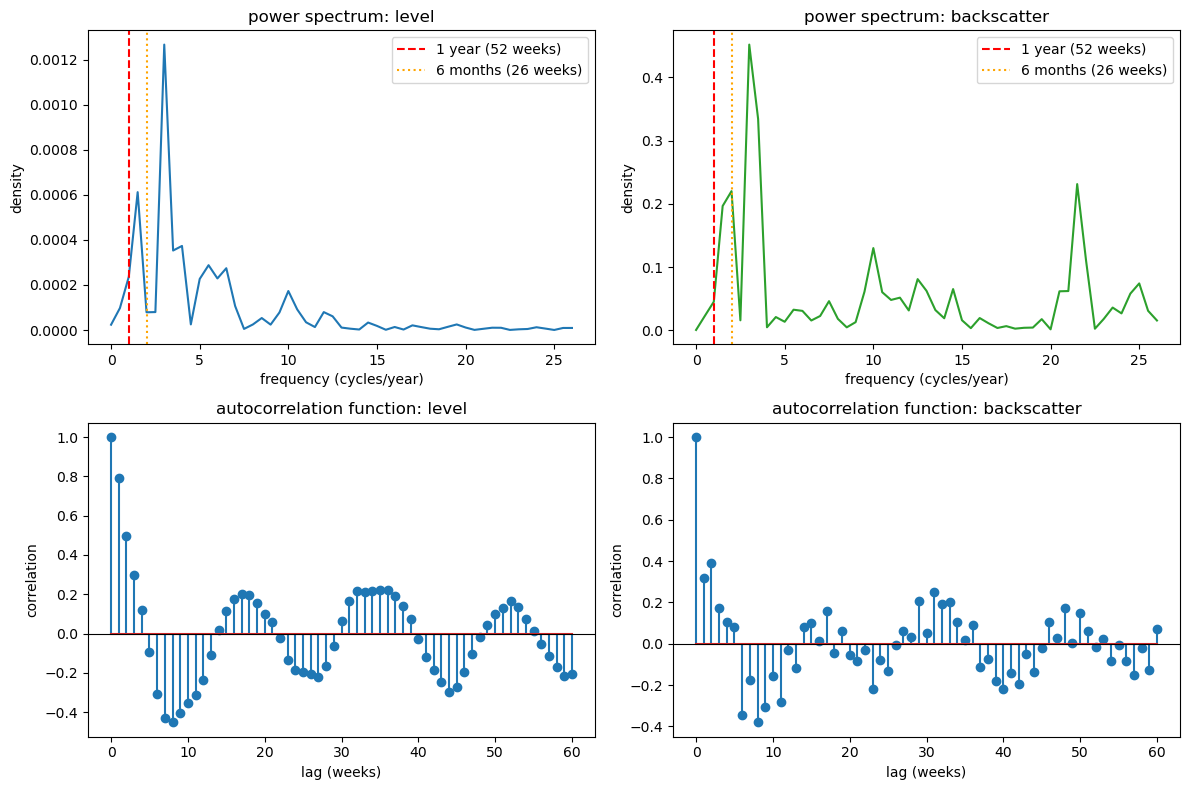

In [2124]:
diagnostic_level_norm_2 = analyze_series_diagnostics(water_table_anom)
diagnostic_sar_norm_2 = analyze_series_diagnostics(backscatter_anom)
#diagnostic_sar_norm_cleaned_2 = analyze_series_diagnostics(backscatter_clean)

plot_series_diagnostics(diagnostic_level_norm_2, diagnostic_sar_norm_2)

<Axes: >

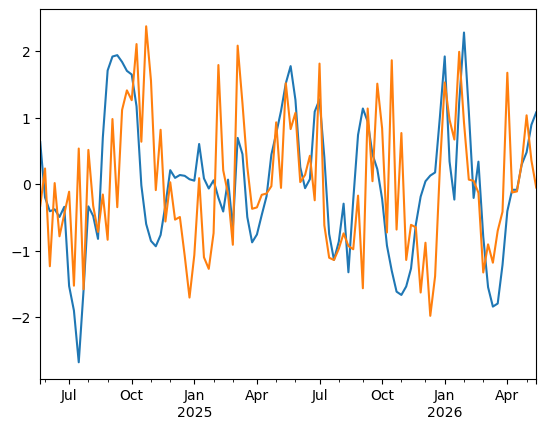

In [2125]:
x_input.plot()
y_input.plot()

In [2126]:
xbh_results_conditioned

{'lags': array([0, 1, 2, 3, 4]),
 'ccf': array([0.32068377, 0.32081891, 0.30253886, 0.33239705, 0.26810576]),
 'rho_critical': array([0.38388477, 0.38187333, 0.37985114, 0.37781801, 0.37577377]),
 'is_significant': array([False, False, False, False, False]),
 'v_effective': array([28.59775287, 28.3301409 , 28.06257672, 27.79506219, 27.52759785]),
 'delta': array([0.29420916, 0.29446739, 0.29473114, 0.29500062, 0.29527598]),
 'n_independent': np.float64(1.4710458108626812),
 'alpha_adjusted': np.float64(0.034267685943667914),
 'peak_lag': np.int64(3),
 'peak_ccf': np.float64(0.33239705194019875),
 'is_peak_significant': False}

In [2127]:
mc_results_conditioned

{'lags': array([0, 1, 2, 3, 4]),
 'observed_ccf': array([0.32068377, 0.32081891, 0.30253886, 0.33239705, 0.26810576]),
 'peak_lag': np.int64(3),
 'peak_correlation': np.float64(0.33239705194019875),
 'critical_threshold_pointwise': array([0.35117705, 0.34571225, 0.34215967, 0.34355419, 0.34303581]),
 'critical_threshold_peak': np.float64(0.39489835085097696),
 'empirical_p_value': np.float64(0.195),
 'is_peak_significant': False}

Usar armonicos de 1 en nivel y retro condicionado (pp), XBH da una correlacion significativa de 0.4536 en el lag 3, pero los grados de libertad son <35. Al evaluar con MC, da el mismo valor de correlacion, pero no logra superar el umbral global de rho=0.4877 (con 7 lags evaluados)
En el mismo escenario, pero con retro no condicionada a pp, XBH obtiene una corr sign de 0.4483 en el lag 3 y con gl <35. Al evaluar con MC tampoco se logra superar el umbral global de rho=0.4732.
Esto me hace pensar que el condicionamiento de la precipitación no está sumando mucho.

Usar armonico = 1 en ambos, evaluando 4 lags y 100000 simulaciones MC da significancia en el lag +3

No obstante me queda la duda de si estoy aplicando las transformaciones correctas. Cuando subo a dos harmónicos, el lag se desplaza al valor 0 ¿por qué ocurre eso? Estoy forzando el resultado al usar 1 harmonico?

##### Evaluar efecto de filtrar la pp

In [2128]:
def calculate_regression_diagnostics(observed_series, fitted_series, residual_series):
    """
    Compute total variance, residual variance, explained variance, and R-squared.
    """
    observed_array = np.asarray(observed_series, dtype=float)
    fitted_array = np.asarray(fitted_series, dtype=float)
    residual_array = np.asarray(residual_series, dtype=float)
    
    total_variance = np.var(observed_array, ddof=0)
    residual_variance = np.var(residual_array, ddof=0)
    # CHANGED: UTILIZED FITTED_SERIES TO COMPUTE EXPLAINED VARIANCE DIRECTLY
    explained_variance = np.var(fitted_array, ddof=0)
    
    if total_variance == 0.0:
        determination_coefficient = 0.0
    else:
        determination_coefficient = 1.0 - (residual_variance / total_variance)
        
    return {
        'total_variance': total_variance,
        'residual_variance': residual_variance,
        'explained_variance': explained_variance,
        'r_squared': determination_coefficient
    }


def evaluate_precipitation_orthogonality(residual_backscatter, precipitation_series, max_lag=5):
    """
    Verify that the residual backscatter is strictly decoupled from precipitation at key lags.
    """
    sample_size = len(residual_backscatter)
    centered_residuals = residual_backscatter - np.mean(residual_backscatter)
    centered_precip = precipitation_series - np.mean(precipitation_series)
    
    std_residuals = np.std(centered_residuals, ddof=0)
    std_precip = np.std(centered_precip, ddof=0)
    
    residual_correlations = {}
    for lag in range(max_lag + 1):
        if lag == 0:
            cov = np.sum(centered_residuals * centered_precip) / sample_size
        else:
            cov = np.sum(centered_residuals[lag:] * centered_precip[:-lag]) / sample_size
        residual_correlations[f'lag_{lag}'] = cov / (std_residuals * std_precip)
        
    return residual_correlations


def plot_precipitation_removal_diagnostics(
    raw_backscatter, 
    cleaned_backscatter, 
    precipitation_series, 
    regime_mask
):
    """
    Plot time series comparisons and diagnostic metrics before and after precipitation decoupling.
    """
    num_points = len(raw_backscatter)
    time_steps = np.arange(num_points)
    
    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={'height_ratios': [1, 2]})
    
    # 1. Precipitation bar plot with regime shading
    axes[0].bar(time_steps, precipitation_series, color='tab:blue', width=0.8, alpha=0.7, label='precipitation')
    axes[0].set_ylabel("rainfall (mm)")
    axes[0].set_title("precipitation and active seasonal regimes")
    
    # Highlight wet season in background
    axes[0].pcolorfast(
        (0, num_points), 
        axes[0].get_ylim(), 
        regime_mask[np.newaxis, :], 
        cmap='Blues', 
        alpha=0.15
    )
    axes[0].legend(loc='upper right')
    
    # 2. Backscatter series comparison
    axes[1].plot(time_steps, raw_backscatter, color='gray', linestyle='--', linewidth=1.2, label='backscatter (before correction)')
    axes[1].plot(time_steps, cleaned_backscatter, color='tab:green', linewidth=1.5, label='backscatter (after rainfall decoupling)')
    axes[1].set_ylabel("backscatter (dB / anomaly)")
    axes[1].set_xlabel("time step (weeks)")
    axes[1].set_title("comparison of backscatter trajectory")
    axes[1].legend(loc='upper right')
    axes[1].grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

Varianza total del backscatter anómalo: 1.5653
Varianza explicada por la lluvia:       0.1253
Varianza residual (señal desacoplada):  1.4400
R² de la corrección por lluvia:        0.0800
Correlación residual con lluvia:
  lag_0: 0.0000
  lag_1: -0.0007
  lag_2: 0.0005
  lag_3: -0.0032
  lag_4: -0.0263
  lag_5: -0.1779


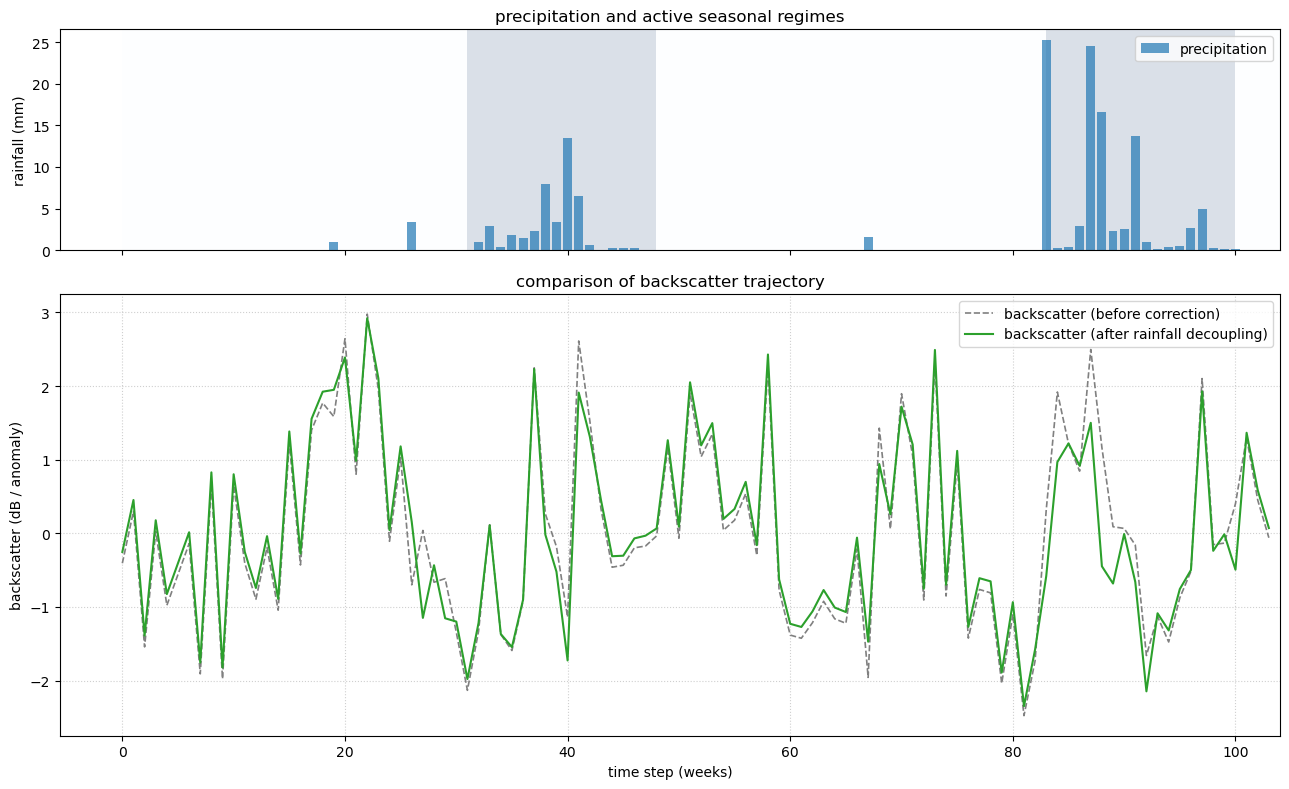

In [2129]:
# A) Cuantificar varianza explicada y reducción de varianza
metrics = calculate_regression_diagnostics(
    observed_series=backscatter_anom,
    fitted_series=fitted_rainfall_signal,
    residual_series=backscatter_clean
)

print(f"Varianza total del backscatter anómalo: {metrics['total_variance']:.4f}")
print(f"Varianza explicada por la lluvia:       {metrics['explained_variance']:.4f}")
print(f"Varianza residual (señal desacoplada):  {metrics['residual_variance']:.4f}")
print(f"R² de la corrección por lluvia:        {metrics['r_squared']:.4f}")

# B) Verificar ortogonalidad (la correlación residual con lluvia debe ser ~ 0)
ortho_checks = evaluate_precipitation_orthogonality(
    residual_backscatter=backscatter_clean,
    precipitation_series=weekly_df['ATMOS41_precipitation_mm'],
    max_lag=5
)
print("Correlación residual con lluvia:")
for lag_key, corr_val in ortho_checks.items():
    print(f"  {lag_key}: {corr_val:.4f}")

# C) Graficar la comparación de series y regímenes
plot_precipitation_removal_diagnostics(
    raw_backscatter=backscatter_anom,
    cleaned_backscatter=backscatter_clean,
    precipitation_series=weekly_df['ATMOS41_precipitation_mm'],
    regime_mask=regime_mask
)

### Antiguo

##### Subset por precipitaciones

Probabré primero a filtrar las semanas con precipitaciones. Si no tengo buenos resultados, podría probar a filtrar los días + n siguientes con lluvias y luego hacer el resampleo.

Una vez que elimine las semanas con precipitaciones, no puedo dejar nan porque falla la correlación cruzada ¿cual es la mejor opcion? ¿rellenar con el valor promedio? ¿normalizar y rellenar con 0 (media)?

In [2130]:
# def subset_by_meteo(df, min_pp = 0.0):
#     """
#     Subdivide un df en funcion de condiciones meteorologicas
#     """
#     # Establece condicion
#     rained = df['ATMOS41_precipitation_mm'] > min_pp

#     # Divide los df con la mascara
#     rain = df[rained]
#     no_rain = df[~rained]

#     return rain, no_rain

In [2131]:
# insitu_weekly_rain, insitu_weekly_no_rain = subset_by_meteo(insitu_weekly, 0.0)

In [2132]:
# fp1 = '../outputs/predictions/SDH1_2000-2026_first-year.csv'
# modeled1 = load_and_prepare_data(fp1)

# # Reindexar a frecuencia semanal
# modeled1_weekly = modeled1[['predicted']].resample('W').mean()

# # Clipear al rango S1
# modeled1_weekly = slice_by_dates(modeled1_weekly, '2017-02')

In [2133]:
# modeled1_weekly['predicted']

In [2134]:
# s1_weekly['VV_38.5_weekly']

#### Correlaciones cruzadas

##### Iteración 1: backscatter normalizado a 38.5° y nivel modelado (2017-2026)

In [2135]:
res = cross_correlation_xbh(s1_weekly['VV_38.5_weekly'], modeled1_weekly['predicted'], max_lag=10, alpha=0.05)
    
print(f"Número de desfases independientes (n_i): {res['n_independent']:.2f}")
print(f"Alpha ajustado por búsqueda de rango (alpha_c): {res['alpha_adjusted']:.4f}")
print(f"Picos con correlación significativa: {np.sum(res['is_significant'])} de {len(res['lags'])}")

lags = res['lags']
ccf = res['ccf']
sig_mask = res['is_significant']

if np.any(sig_mask):
    # Índices de los lags significativos
    sig_indices = np.where(sig_mask)[0]
    
    # Índice del lag significativo con la mayor correlación absoluta
    best_idx = sig_indices[np.argmax(np.abs(ccf[sig_indices]))]
    
    optimal_lag = lags[best_idx]
    optimal_ccf = ccf[best_idx]
    crit_val = res['rho_critical'][best_idx]
    
    print(f"Lag óptimo: {optimal_lag}")
    print(f"CCF observada: {optimal_ccf:.4f} (Umbral crítico: ±{crit_val:.4f})")
else:
    print("No se encontró ningún lag estadísticamente significativo.")


Número de desfases independientes (n_i): 1.05
Alpha ajustado por búsqueda de rango (alpha_c): 0.0475
Picos con correlación significativa: 7 de 21
Lag óptimo: 8
CCF observada: -0.5296 (Umbral crítico: ±0.3987)


In [2136]:
res

{'lags': array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
          3,   4,   5,   6,   7,   8,   9,  10]),
 'ccf': array([ 0.1057282 ,  0.09173796,  0.09291473,  0.09010036,  0.09372986,
         0.10372933,  0.08964653,  0.07478024,  0.04100974,  0.01249038,
        -0.0397817 , -0.14540112, -0.24004886, -0.33378379, -0.40765315,
        -0.46435044, -0.50567878, -0.5199698 , -0.52964199, -0.50144679,
        -0.47701603]),
 'rho_critical': array([0.397644  , 0.39815543, 0.39866618, 0.39917626, 0.39968567,
        0.40019442, 0.40070251, 0.40120994, 0.40171671, 0.40222283,
        0.4027283 , 0.40222283, 0.40171671, 0.40120994, 0.40070251,
        0.40019442, 0.39968567, 0.39917626, 0.39866618, 0.39815543,
        0.397644  ]),
 'is_significant': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False,  True,  True,  True,  True,
         True,  True,  True]),
 'v_effective': array([22.29640275, 22.3340785

##### Iteración 2: backscatter y nivel observado con pp removidas por método de ortogonalización

In [2137]:
import numpy as np
import pandas as pd
from scipy import stats

# 1. Alinear datasets por DateTimeIndex y eliminar semanas sin coincidencia
df = pd.concat([
    s1_weekly['VV_38.5_weekly'],
    insitu_weekly[['SDH1PS01_gw-depth_m', 'ATMOS41_precipitation_mm']]
], axis=1).dropna()

# 2. Construcción de matrices
N = len(df)
x = df['VV_38.5_weekly'].to_numpy(dtype=float)
y = df['SDH1PS01_gw-depth_m'].to_numpy(dtype=float)
precip = df['ATMOS41_precipitation_mm'].to_numpy(dtype=float)

# Matriz de proyección ortogonal M_Z
Z = np.column_stack([np.ones(N), precip])
# Proyección de x e y sobre el complemento ortogonal de Z
# M_Z * v = v - Z * (Z^T Z)^(-1) * Z^T * v
beta_x, _, _, _ = np.linalg.lstsq(Z, x, rcond=None)
beta_y, _, _, _ = np.linalg.lstsq(Z, y, rcond=None)

x_star = x - Z @ beta_x
y_star = y - Z @ beta_y

# Verificación matemática (las correlaciones con la lluvia deben ser ~0)
corr_x_precip = np.corrcoef(x_star, precip)[0, 1]
corr_y_precip = np.corrcoef(y_star, precip)[0, 1]
print(f"Correlación residual x* con precipitación: {corr_x_precip:.2e}")
print(f"Correlación residual y* con precipitación: {corr_y_precip:.2e}")

# 3. Ejecutar cross_correlation_xbh sobre las series ortogonalizadas
res2 = cross_correlation_xbh(x_star, y_star, max_lag=10, alpha=0.05)

# 4. Extracción y evaluación del lag óptimo
lags = res2['lags']
ccf = res2['ccf']
sig_mask = res2['is_significant']

if np.any(sig_mask):
    sig_indices = np.where(sig_mask)[0]
    best_idx = sig_indices[np.argmax(np.abs(ccf[sig_indices]))]
    
    print(f"\nLag óptimo: {lags[best_idx]} semanas")
    print(f"CCF observada: {ccf[best_idx]:.4f}")
    print(f"Umbral crítico: ±{res2['rho_critical'][best_idx]:.4f}")
    print(f"Grados de libertad efectivos (nu): {res2['v_effective'][best_idx]:.1f}")
else:
    print("\nNo se encontraron desfases significativos tras remover el componente lineal de la precipitación.")


Correlación residual x* con precipitación: 3.28e-16
Correlación residual y* con precipitación: 2.36e-16

Lag óptimo: 6 semanas
CCF observada: -0.6158
Umbral crítico: ±0.5719
Grados de libertad efectivos (nu): 13.1


In [2138]:
res2

{'lags': array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
          3,   4,   5,   6,   7,   8,   9,  10]),
 'ccf': array([ 0.15245574,  0.16061241,  0.17482748,  0.17736685,  0.19267344,
         0.16710222,  0.09620385,  0.0472359 , -0.00285948, -0.06429427,
        -0.17456179, -0.32338245, -0.40087082, -0.46407333, -0.52009234,
        -0.57799413, -0.61582923, -0.60277624, -0.59174994, -0.54389507,
        -0.48699721]),
 'rho_critical': array([0.55697661, 0.56075198, 0.56449972, 0.56822177, 0.57191901,
        0.57559244, 0.57924269, 0.58287049, 0.58647638, 0.59006079,
        0.59362411, 0.59006079, 0.58647638, 0.58287049, 0.57924269,
        0.57559244, 0.57191901, 0.56822177, 0.56449972, 0.56075198,
        0.55697661]),
 'is_significant': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False,  True,  True,  True,
         True, False, False]),
 'v_effective': array([12.64443604, 12.7645964

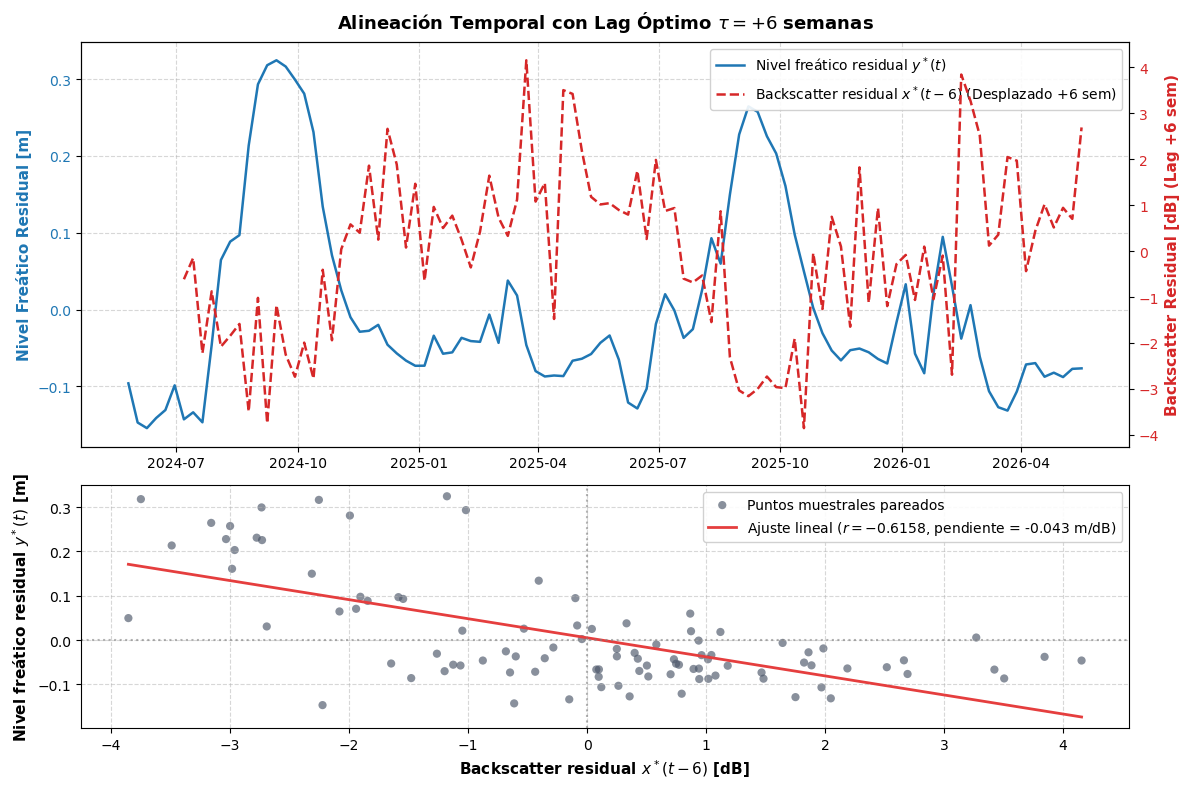

In [2139]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Crear un DataFrame con las series ortogonalizadas (o las originales)
# Usando el índice temporal común obtenido en el paso de ortogonalización
df_aligned = pd.DataFrame({
    'water_table_res': y_star,    # Nivel freático residual [m]
    'backscatter_res': x_star     # Backscatter residual [dB]
}, index=df.index)

# 2. Aplicar el desplazamiento de 6 semanas al backscatter
LAG_OPT = 6
df_aligned['backscatter_shifted'] = df_aligned['backscatter_res'].shift(LAG_OPT)

# 3. Configuración de la figura (2 paneles: Serie Temporal y Dispersión)
fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    figsize=(12, 8), 
    gridspec_kw={'height_ratios': [2, 1.2]}
)

# --- PANEL 1: SERIES TEMPORALES ALINEADAS (DOBLE EJE Y) ---
color_gw = '#1f77b4'   # Azul para nivel freático
color_s1 = '#d62728'   # Rojo para Sentinel-1

# Eje izquierdo: Nivel freático
ax1.plot(
    df_aligned.index, 
    df_aligned['water_table_res'], 
    color=color_gw, 
    linewidth=1.8, 
    label=r'Nivel freático residual $y^*(t)$'
)
ax1.set_ylabel('Nivel Freático Residual [m]', color=color_gw, fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_gw)
ax1.grid(True, linestyle='--', alpha=0.5)

# Eje derecho: Backscatter desplazado +6 semanas
ax1_twin = ax1.twinx()
ax1_twin.plot(
    df_aligned.index, 
    df_aligned['backscatter_shifted'], 
    color=color_s1, 
    linestyle='--', 
    linewidth=1.8, 
    label=rf'Backscatter residual $x^*(t - {LAG_OPT})$ (Desplazado +{LAG_OPT} sem)'
)
ax1_twin.set_ylabel(f'Backscatter Residual [dB] (Lag +{LAG_OPT} sem)', color=color_s1, fontsize=11, fontweight='bold')
ax1_twin.tick_params(axis='y', labelcolor=color_s1)

# Leyenda unificada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', framealpha=0.9)
ax1.set_title(rf'Alineación Temporal con Lag Óptimo $\tau = +{LAG_OPT}$ semanas', fontsize=13, fontweight='bold', pad=10)

# --- PANEL 2: SCATTER PLOT Y RECTA DE AJUSTE LINEAL ---
df_pairs = df_aligned[['backscatter_shifted', 'water_table_res']].dropna()
x_pts = df_pairs['backscatter_shifted'].to_numpy()
y_pts = df_pairs['water_table_res'].to_numpy()

ax2.scatter(x_pts, y_pts, color='#4a5568', alpha=0.65, s=35, edgecolors='none', label='Puntos muestrales pareados')

# Ajuste lineal por mínimos cuadrados
slope, intercept = np.polyfit(x_pts, y_pts, 1)
x_line = np.linspace(x_pts.min(), x_pts.max(), 100)
y_line = slope * x_line + intercept

ax2.plot(
    x_line, 
    y_line, 
    color='#e53e3e', 
    linewidth=2, 
    label=rf'Ajuste lineal ($r = -0.6158$, pendiente = {slope:.3f} m/dB)'
)
ax2.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax2.axvline(0, color='gray', linestyle=':', alpha=0.6)

ax2.set_xlabel(rf'Backscatter residual $x^*(t - {LAG_OPT})$ [dB]', fontsize=11, fontweight='bold')
ax2.set_ylabel(r'Nivel freático residual $y^*(t)$ [m]', fontsize=11, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()


##### Iteración 3: backscatter y nivel observado con pp removidas con método de regresión linear

In [2140]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Unir las series en un único DataFrame semanal alineado
df_clean = pd.DataFrame({
    'backscatter': s1_weekly['VV_38.5_weekly'],
    'water_table': insitu_weekly['SDH1PS01_gw-depth_m'],
    'precip': insitu_weekly['ATMOS41_precipitation_mm']
}).dropna()

# Matriz 2D de la variable explicativa (precipitación de la semana en curso)
X_precip = df_clean[['precip']]

# 2. Regresión y cálculo de residuos para Backscatter
model_x = LinearRegression()
model_x.fit(X_precip, df_clean['backscatter'])
backscatter_res = df_clean['backscatter'] - model_x.predict(X_precip)

# 3. Regresión y cálculo de residuos para Nivel Freático
model_y = LinearRegression()
model_y.fit(X_precip, df_clean['water_table'])
water_table_res = df_clean['water_table'] - model_y.predict(X_precip)

# 4. Aplicar la función xBH sobre las series libres del efecto directo de la lluvia
res3 = cross_correlation_xbh(
    x=backscatter_res.values,
    y=water_table_res.values,
    max_lag=10,
    alpha=0.05
)

In [2141]:
s1_weekly_2.plot()
backscatter_res.plot()

NameError: name 's1_weekly_2' is not defined

In [ ]:
res3

{'lags': array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
          3,   4,   5,   6,   7,   8,   9,  10]),
 'ccf': array([ 0.15245574,  0.16061241,  0.17482748,  0.17736685,  0.19267344,
         0.16710222,  0.09620385,  0.0472359 , -0.00285948, -0.06429427,
        -0.17456179, -0.32338245, -0.40087082, -0.46407333, -0.52009234,
        -0.57799413, -0.61582923, -0.60277624, -0.59174994, -0.54389507,
        -0.48699721]),
 'rho_critical': array([0.55697661, 0.56075198, 0.56449972, 0.56822177, 0.57191901,
        0.57559244, 0.57924269, 0.58287049, 0.58647638, 0.59006079,
        0.59362411, 0.59006079, 0.58647638, 0.58287049, 0.57924269,
        0.57559244, 0.57191901, 0.56822177, 0.56449972, 0.56075198,
        0.55697661]),
 'is_significant': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False,  True,  True,  True,
         True, False, False]),
 'v_effective': array([12.64443604, 12.7645964